In [26]:
from pathlib import Path
import pandas as pd

freqs = ['30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]

all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            
            # Find the best row
            best_idx = df['bounce_perc'].idxmin()
            best_row = df.loc[[best_idx]].copy()
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_leaderboard = final_leaderboard.sort_values('bounce_perc', ascending=True)


In [27]:
final_leaderboard.tail(5)


,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,atr_param,frequency
19,2,4,365,325,690,52.898551,200,1m
48,2,4,44,39,83,53.012048,500,3m
38,3,5,110,96,206,53.398058,400,3m
34,0,2,12,10,22,54.545455,350,1m
29,2,4,131,104,235,55.744681,300,1m


In [28]:
from pathlib import Path
import pandas as pd

freqs = ['30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]

all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['score'] = atr * (2 * df['bounce_perc'] - 100) * df['total']
            
            # Find the best row
            best_idx = df['score'].idxmax()
            best_row = df.loc[[best_idx]].copy() # Using [[]] keeps it as a DataFrame
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_leaderboard = final_leaderboard.sort_values('score', ascending=False)


In [29]:
final_leaderboard.tail(5)


,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,score,atr_param,frequency
2,49,51,104,65,169,61.538462,195000.0,50,5m
10,336,338,15,3,18,83.333333,180000.0,150,30m
6,138,140,26,9,35,74.285714,170000.0,100,15m
1,15,17,47,30,77,61.038961,85000.0,50,15m
0,30,32,12,4,16,75.000000,40000.0,50,30m


In [30]:
from pathlib import Path
import pandas as pd

freqs = ['1d', '12h', '8h', '6h', '4h', '2h', '1h', '30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]


all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['score'] = atr * (100 - 2 * df['bounce_perc']) * df['total']
            
            # Find the best row
            best_idx = df['score'].idxmax()
            best_row = df.loc[[best_idx]].copy() # Using [[]] keeps it as a DataFrame
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_pen_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_pen_leaderboard = final_pen_leaderboard.sort_values('score', ascending=False)


In [31]:
final_pen_leaderboard.tail(5)


,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,score,atr_param,frequency
58,0,2,74,64,138,53.623188,-250000.0,250,3m
59,1,3,124,114,238,52.100840,-250000.0,250,1m
82,0,2,27,19,46,58.695652,-280000.0,350,3m
47,0,2,85,70,155,54.838710,-300000.0,200,1m
94,0,2,20,11,31,64.516129,-360000.0,400,3m


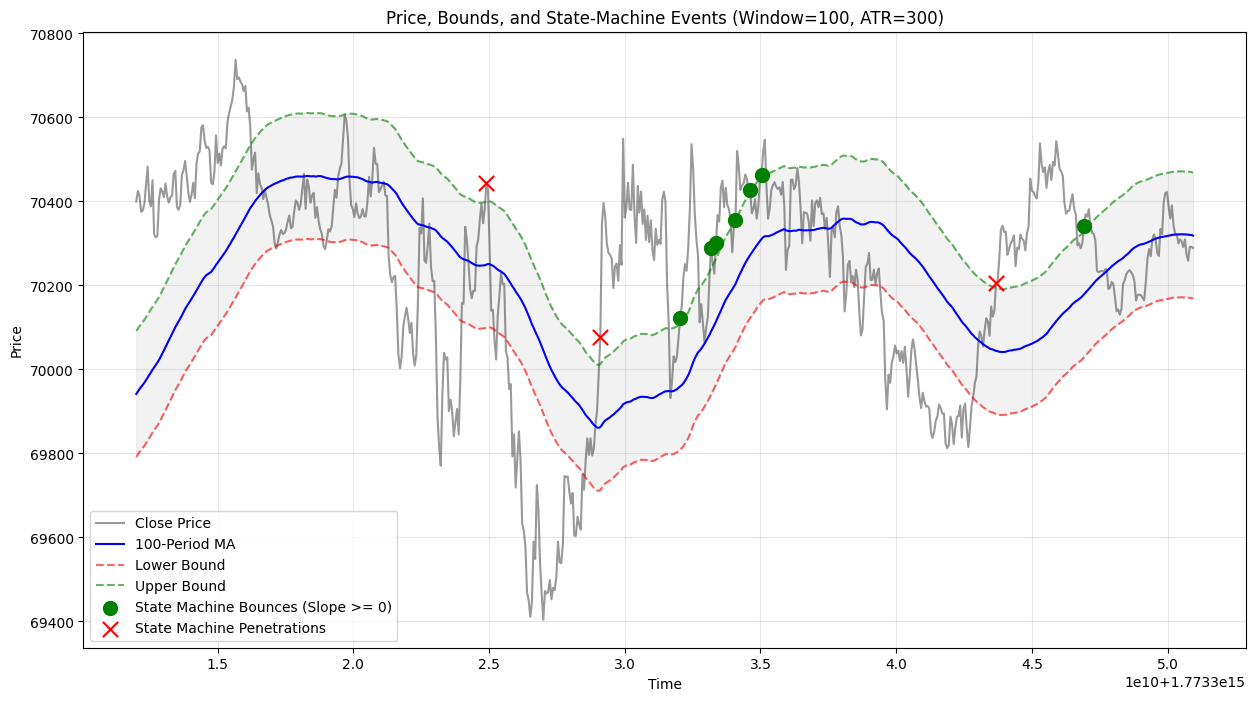

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from bounce_percentages import calculate_market_events
from bounce_slope_filters import get_nonnegative_slope_timestamps
import glob
import os
from pathlib import Path



# Parameters
atr = 300

rw = 100  # Example window size
freq = '1m'


try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()
    if SCRIPT_DIR.name != 'discovery':
        SCRIPT_DIR = SCRIPT_DIR / 'bot' / 'strategy' / 'discovery'
REPO_ROOT = SCRIPT_DIR.parents[2]
DATA_ROOT = REPO_ROOT / 'bot' / 'data' / 'data' / 'spot' / 'daily' / 'klines' / 'BTCUSDT'
path = DATA_ROOT / freq / '2026-02-12_2026-03-12'

# path = f'/home/ora/Desktop/luma/almaty-lake-capital/bot/data/data/spot/daily/klines/BTCUSDT/1m/2026-01-11_2026-03-13'


all_files = glob.glob(os.path.join(path, "*.csv"))
cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 
        'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 
        'taker_buy_quote_asset_volume', 'ignore']
# Data Loading
df_list = [pd.read_csv(f, header=None, names=cols) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
df = df.sort_values('open_time').reset_index(drop=True)

# Calculations
ma = df['close'].rolling(window=rw).mean()
ma = ma[-800:-150]
df=df[-800:-150]
l_bound = ma - atr * 0.5
u_bound = ma + atr * 0.5

bounce_indices, pen_indices = calculate_market_events(df['close'], l_bound, u_bound, rw)
nonnegative_slope_timestamps = get_nonnegative_slope_timestamps(df['open_time'], u_bound, window=75)
filtered_bounce_indices = df.loc[bounce_indices, 'open_time']
filtered_bounce_indices = filtered_bounce_indices[
    filtered_bounce_indices.isin(nonnegative_slope_timestamps)
].index.tolist()

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(df['open_time'], df['close'], label='Close Price', color='black', alpha=0.4)
plt.plot(df['open_time'], ma, label=f'{rw}-Period MA', color='blue', linewidth=1.5)
plt.plot(df['open_time'], l_bound, label='Lower Bound', color='red', linestyle='--', alpha=0.6)
plt.plot(df['open_time'], u_bound, label='Upper Bound', color='green', linestyle='--', alpha=0.6)

# Plot Bounces
plt.scatter(df.loc[filtered_bounce_indices, 'open_time'], df.loc[filtered_bounce_indices, 'close'],
            color='green', marker='o', s=100, label='State Machine Bounces (Slope >= 0)', zorder=5)

# Plot Penetrations
plt.scatter(df.loc[pen_indices, 'open_time'], df.loc[pen_indices, 'close'],
            color='red', marker='x', s=120, label='State Machine Penetrations', zorder=5)

plt.fill_between(df['open_time'], l_bound, u_bound, color='gray', alpha=0.1)
plt.title(f'Price, Bounds, and State-Machine Events (Window={rw}, ATR={atr})')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


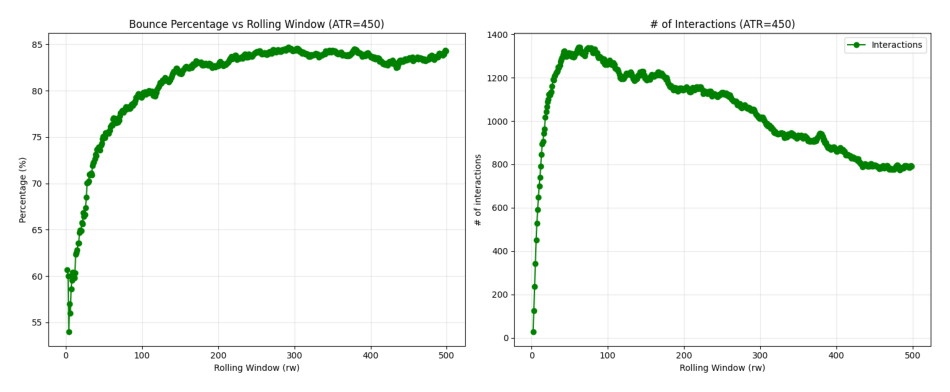

In [ ]:
import pandas as pd
freq = '1m'
atr = 450
path = f'/home/ora/Desktop/luma/almaty-lake-capital/bot/strategy/discovery/figures/{atr}/{freq}_bounce_percentage.png'
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.figure(figsize=(12, 8))
# Load the image
img = mpimg.imread(path)

# Display the image
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()
